## Modeling

#### Import thư viện

In [29]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss, confusion_matrix, classification_report
from xgboost import XGBClassifier
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

### CẤU HÌNH ĐƯỜNG DẪN VÀ THAM SỐ

In [30]:
# --- CẤU HÌNH ĐƯỜNG DẪN VÀ THAM SỐ ---
BASE_PATH = 'C:\\Users\\hienm\\OneDrive\\Desktop\\Machine_Learning_2025-2026\\challange3\\data\\data_afterfix\\'
TRAIN_FILE = os.path.join(BASE_PATH, 'train_features_final.csv')
TEST_FILE = os.path.join(BASE_PATH, 'test_features_final.csv')
TEST_ID_FILE = 'C:\\Users\\hienm\\OneDrive\\Desktop\\Machine_Learning_2025-2026\\challange3\\data\\test.csv' # File test gốc để lấy cột Id

In [31]:
N_SPLITS = 5 # Số lần chia trong K-Fold
RANDOM_STATE = 42
TARGET_COL = 'Class'

print("--- BẮT ĐẦU QUY TRÌNH ML PIPELINE ---")

# Đọc file dữ liệu đã xử lý
try:
    df_train = pd.read_csv(TRAIN_FILE)
    df_test_features = pd.read_csv(TEST_FILE)
    
    # Đọc file test gốc để lấy cột ID
    df_test_original = pd.read_csv(TEST_ID_FILE) 
    test_ids = df_test_original['Id']
    
    # Chuẩn bị dữ liệu
    X = df_train.drop(columns=[TARGET_COL])
    y = df_train[TARGET_COL]
    X_test = df_test_features.copy()
    
    print(f"Đã đọc Train ({X.shape}) và Test ({X_test.shape}) thành công.")

except FileNotFoundError as e:
    print(f"Lỗi: Không tìm thấy file cần thiết. Vui lòng kiểm tra lại đường dẫn: {e}")
    exit()

--- BẮT ĐẦU QUY TRÌNH ML PIPELINE ---
Đã đọc Train ((14396, 38)) và Test ((3600, 38)) thành công.


### KHAI BÁO THAM SỐ CHO TỐI ƯU (HYPERPARAMETER TUNING)

In [32]:
# Chọn một số tham số quan trọng để tìm kiếm nhanh
param_grid_rf = {'n_estimators': [100, 200], 'max_depth': [10, 20]}
param_grid_xgb = {'n_estimators': [100, 200], 'max_depth': [5, 7], 'learning_rate': [0.1, 0.05]}
param_grid_lgb = {'n_estimators': [100, 200], 'max_depth': [5, 10], 'learning_rate': [0.1, 0.05]}
param_grid_svc_rbf = {'C': [1, 10], 'gamma': [0.01, 0.1]} 
param_grid_gbm = {'n_estimators': [100, 200], 'learning_rate': [0.1, 0.05], 'max_depth': [3, 5]}
param_grid_mlp = {'hidden_layer_sizes': [(50,), (50, 20)], 'alpha': [0.0001, 0.01], 'max_iter': [300]}

### K-Fold

In [33]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

### Hàm đánh giá mô hình

In [34]:
# Định nghĩa hàm huấn luyện, tối ưu và đánh giá
def train_evaluate_and_submit(model, param_grid, model_name):
    """Huấn luyện mô hình, tối ưu tham số, đánh giá và tạo submission.
       FIX: Xử lý triệt để NaN bằng cách dùng X_to_use thay vì X."""
    
    # Sử dụng X và X_test GLOBAL được load từ đầu file
    global X, X_test, y, test_ids, skf, BASE_PATH
    
    print(f"\n================ BẮT ĐẦU: {model_name} ================")
    
    # 0. XỬ LÝ LỖI NaN (BƯỚC FIX QUAN TRỌNG)
    print("-> 0. Đang xử lý các giá trị NaN còn sót lại trong X và X_test bằng median...")
    # Tính toán median CHỈ TỪ TẬP TRAIN (X)
    imputer_medians = X.median()
    
    # Áp dụng imputation cho cả Train và Test (Sử dụng các phiên bản đã fillna)
    X_to_use = X.fillna(imputer_medians)
    X_test_to_use = X_test.fillna(imputer_medians)
    
    print(f"-> Xử lý NaN hoàn tất. Số lượng NaN trong X_to_use: {X_to_use.isnull().sum().sum()}")
    
    # 1. Tối ưu tham số (Grid Search)
    print("-> 1. Đang thực hiện Grid Search để tối ưu tham số...")
    # Sử dụng 'f1_weighted' làm chỉ số chính cho phân loại đa lớp
    grid_search = GridSearchCV(model, param_grid, cv=skf, scoring='f1_weighted', n_jobs=-1, verbose=1)
    
    # SỬ DỤNG DỮ LIỆU ĐÃ IMUTE: X_to_use
    grid_search.fit(X_to_use, y) 
    
    best_model = grid_search.best_estimator_
    print(f"-> Tham số tối ưu (Best Params): {grid_search.best_params_}")
    
    # 2. Dự đoán trên tập Train (Dùng cho đánh giá)
    # SỬ DỤNG DỮ LIỆU ĐÃ IMUTE: X_to_use
    y_pred_train = best_model.predict(X_to_use)
    y_proba_train = best_model.predict_proba(X_to_use) # Cần cho Log Loss và ROC AUC
    
    # 3. Đánh giá Mô hình
    print("\n-> 3. Kết quả đánh giá trên tập TRAIN:")
    
    # A. Accuracy
    acc = accuracy_score(y, y_pred_train)
    print(f"   - **Accuracy**: {acc:.4f}")
    
    # B. F1-Score (Weighted)
    f1_w = f1_score(y, y_pred_train, average='weighted')
    print(f"   - **F1-Score (Weighted)**: {f1_w:.4f}")
    
    # C. Log Loss
    ll = log_loss(y, y_proba_train)
    print(f"   - **Log Loss**: {ll:.4f}")
    
    # D. ROC AUC (OvR - One vs. Rest, Weighted)
    try:
        roc_auc = roc_auc_score(y, y_proba_train, multi_class='ovr', average='weighted')
        print(f"   - **ROC AUC (Weighted)**: {roc_auc:.4f}")
    except ValueError:
        print("   - **ROC AUC (Weighted)**: Không tính được.")

    # E. Confusion Matrix (Ma trận Nhầm lẫn)
    cm = confusion_matrix(y, y_pred_train)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Dự đoán (Predicted)')
    plt.ylabel('Thực tế (Actual)')
    plt.show() 


    # F. Classification Report (Chi tiết Precision, Recall, F1 cho từng Class)
    print("\n   - Classification Report:")
    print(classification_report(y, y_pred_train))
    
    # 4. Dự đoán trên tập Test và Tạo Submission
    print("-> 4. Dự đoán trên tập TEST và Tạo file Submission...")
    # SỬ DỤNG DỮ LIỆU ĐÃ IMUTE: X_test_to_use
    y_test_pred = best_model.predict(X_test_to_use)
    
    submission_df = pd.DataFrame({
        'Id': test_ids,
        'Class': y_test_pred.astype(int) 
    })
    
    submission_file = os.path.join(BASE_PATH, f'submission_{model_name.replace(" ", "_").lower()}.csv')
    submission_df.to_csv(submission_file, index=False)
    print(f"-> Đã tạo file submission thành công: {submission_file}")
    print(f"================ KẾT THÚC: {model_name} ================")

### Huấn luyện và Đánh giá 4 Mô hình


================ BẮT ĐẦU: SVC (RBF Kernel) ================
-> 0. Đang xử lý các giá trị NaN còn sót lại trong X và X_test bằng median...
-> Xử lý NaN hoàn tất. Số lượng NaN trong X_to_use: 0
-> 1. Đang thực hiện Grid Search để tối ưu tham số...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
-> Tham số tối ưu (Best Params): {'C': 1, 'gamma': 0.1}

-> 3. Kết quả đánh giá trên tập TRAIN:
   - **Accuracy**: 0.5900
   - **F1-Score (Weighted)**: 0.5789
   - **Log Loss**: 1.0351
   - **ROC AUC (Weighted)**: 0.8971


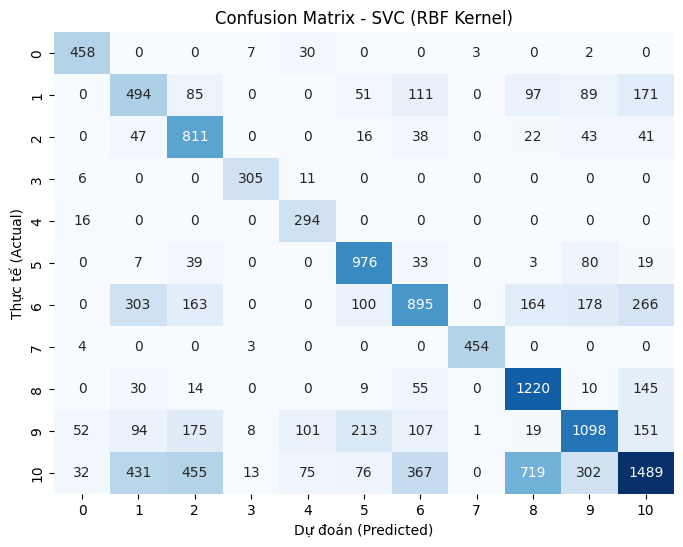


   - Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.92      0.86       500
           1       0.35      0.45      0.39      1098
           2       0.47      0.80      0.59      1018
           3       0.91      0.95      0.93       322
           4       0.58      0.95      0.72       310
           5       0.68      0.84      0.75      1157
           6       0.56      0.43      0.49      2069
           7       0.99      0.98      0.99       461
           8       0.54      0.82      0.65      1483
           9       0.61      0.54      0.57      2019
          10       0.65      0.38      0.48      3959

    accuracy                           0.59     14396
   macro avg       0.65      0.73      0.67     14396
weighted avg       0.61      0.59      0.58     14396

-> 4. Dự đoán trên tập TEST và Tạo file Submission...
-> Đã tạo file submission thành công: C:\Users\hienm\OneDrive\Desktop\Machine_Learning_2025-2026\challan

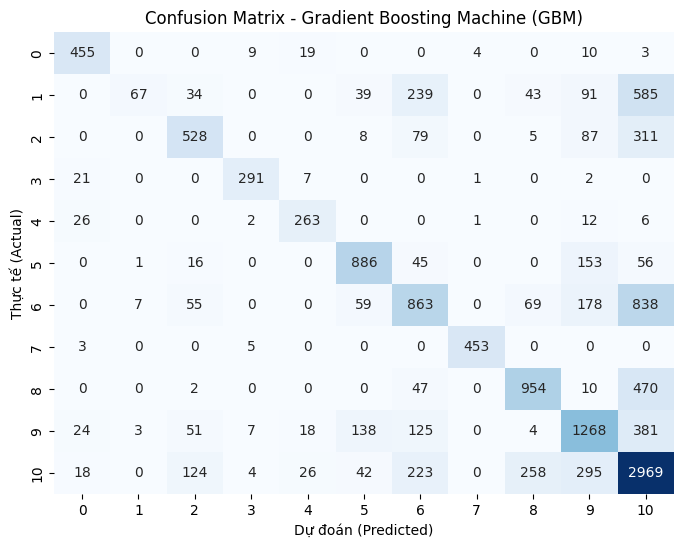


   - Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       500
           1       0.86      0.06      0.11      1098
           2       0.65      0.52      0.58      1018
           3       0.92      0.90      0.91       322
           4       0.79      0.85      0.82       310
           5       0.76      0.77      0.76      1157
           6       0.53      0.42      0.47      2069
           7       0.99      0.98      0.98       461
           8       0.72      0.64      0.68      1483
           9       0.60      0.63      0.61      2019
          10       0.53      0.75      0.62      3959

    accuracy                           0.62     14396
   macro avg       0.74      0.68      0.67     14396
weighted avg       0.65      0.62      0.60     14396

-> 4. Dự đoán trên tập TEST và Tạo file Submission...
-> Đã tạo file submission thành công: C:\Users\hienm\OneDrive\Desktop\Machine_Learning_2025-2026\challan

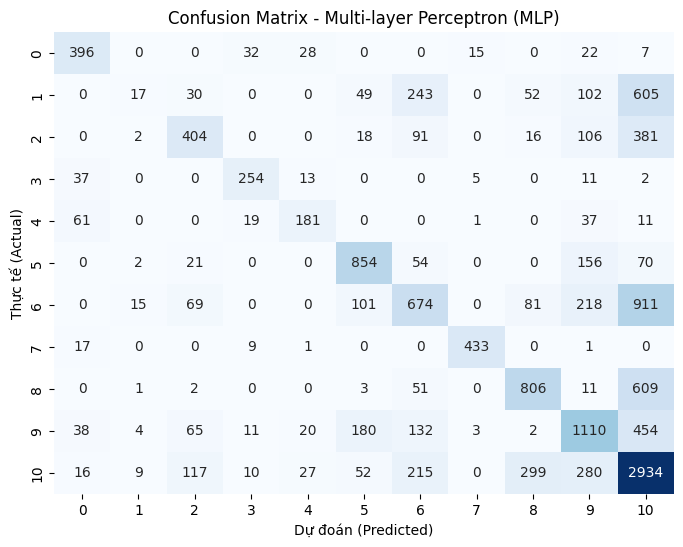


   - Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.79      0.74       500
           1       0.34      0.02      0.03      1098
           2       0.57      0.40      0.47      1018
           3       0.76      0.79      0.77       322
           4       0.67      0.58      0.62       310
           5       0.68      0.74      0.71      1157
           6       0.46      0.33      0.38      2069
           7       0.95      0.94      0.94       461
           8       0.64      0.54      0.59      1483
           9       0.54      0.55      0.55      2019
          10       0.49      0.74      0.59      3959

    accuracy                           0.56     14396
   macro avg       0.62      0.58      0.58     14396
weighted avg       0.55      0.56      0.53     14396

-> 4. Dự đoán trên tập TEST và Tạo file Submission...
-> Đã tạo file submission thành công: C:\Users\hienm\OneDrive\Desktop\Machine_Learning_2025-2026\challan

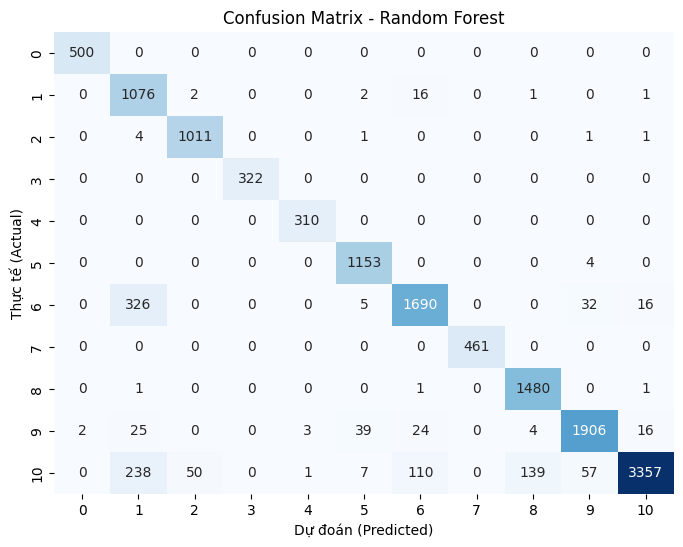


   - Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       500
           1       0.64      0.98      0.78      1098
           2       0.95      0.99      0.97      1018
           3       1.00      1.00      1.00       322
           4       0.99      1.00      0.99       310
           5       0.96      1.00      0.98      1157
           6       0.92      0.82      0.86      2069
           7       1.00      1.00      1.00       461
           8       0.91      1.00      0.95      1483
           9       0.95      0.94      0.95      2019
          10       0.99      0.85      0.91      3959

    accuracy                           0.92     14396
   macro avg       0.94      0.96      0.95     14396
weighted avg       0.94      0.92      0.92     14396

-> 4. Dự đoán trên tập TEST và Tạo file Submission...
-> Đã tạo file submission thành công: C:\Users\hienm\OneDrive\Desktop\Machine_Learning_2025-2026\challan

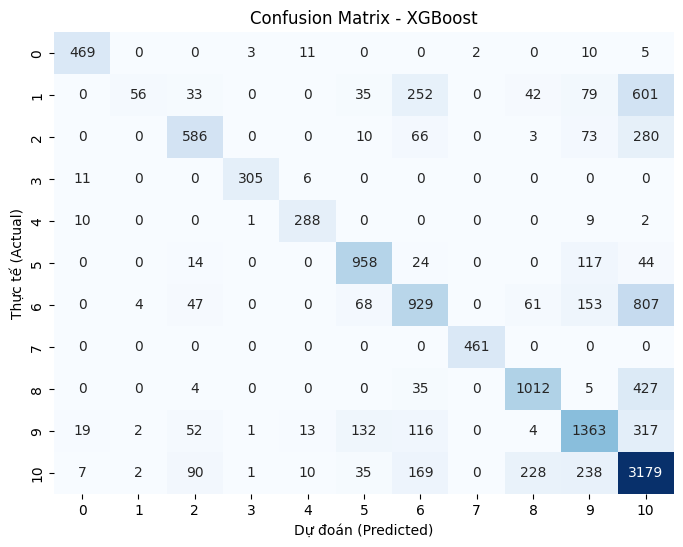


   - Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       500
           1       0.88      0.05      0.10      1098
           2       0.71      0.58      0.64      1018
           3       0.98      0.95      0.96       322
           4       0.88      0.93      0.90       310
           5       0.77      0.83      0.80      1157
           6       0.58      0.45      0.51      2069
           7       1.00      1.00      1.00       461
           8       0.75      0.68      0.71      1483
           9       0.67      0.68      0.67      2019
          10       0.56      0.80      0.66      3959

    accuracy                           0.67     14396
   macro avg       0.79      0.72      0.72     14396
weighted avg       0.69      0.67      0.64     14396

-> 4. Dự đoán trên tập TEST và Tạo file Submission...
-> Đã tạo file submission thành công: C:\Users\hienm\OneDrive\Desktop\Machine_Learning_2025-2026\challan

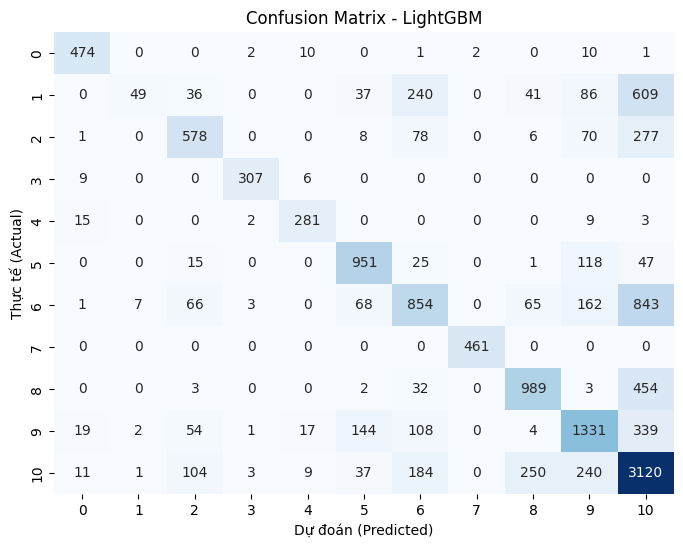


   - Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       500
           1       0.83      0.04      0.08      1098
           2       0.68      0.57      0.62      1018
           3       0.97      0.95      0.96       322
           4       0.87      0.91      0.89       310
           5       0.76      0.82      0.79      1157
           6       0.56      0.41      0.48      2069
           7       1.00      1.00      1.00       461
           8       0.73      0.67      0.70      1483
           9       0.66      0.66      0.66      2019
          10       0.55      0.79      0.65      3959

    accuracy                           0.65     14396
   macro avg       0.77      0.71      0.70     14396
weighted avg       0.67      0.65      0.63     14396

-> 4. Dự đoán trên tập TEST và Tạo file Submission...
-> Đã tạo file submission thành công: C:\Users\hienm\OneDrive\Desktop\Machine_Learning_2025-2026\challan

In [35]:

svc_rbf = SVC(kernel='rbf', 
              probability=True, 
              random_state=RANDOM_STATE, 
              class_weight='balanced')
train_evaluate_and_submit(svc_rbf, param_grid_svc_rbf, "SVC (RBF Kernel)")

# --- 6. GRADIENT BOOSTING MACHINE (GBM) ---
# Mô hình Boosting truyền thống (baseline của XGBoost)
gbm = GradientBoostingClassifier(random_state=RANDOM_STATE)
train_evaluate_and_submit(gbm, param_grid_gbm, "Gradient Boosting Machine (GBM)")

# --- 7. MULTI-LAYER PERCEPTRON (MLP) ---
# Mạng nơ-ron cơ bản (Simple Deep Learning) 
# MLP hoạt động cực kỳ tốt với dữ liệu đã được scale
mlp = MLPClassifier(random_state=RANDOM_STATE)
train_evaluate_and_submit(mlp, param_grid_mlp, "Multi-layer Perceptron (MLP)")

# --- RANDOM FOREST ---
# Cần set class_weight='balanced' do có thể có mất cân bằng giữa 10 lớp
rf = RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced')
train_evaluate_and_submit(rf, param_grid_rf, "Random Forest")

# --- XGBOOST ---
# Sử dụng 'multi:softprob' cho phân loại đa lớp.
xgb = XGBClassifier(objective='multi:softprob', 
                    eval_metric='mlogloss', 
                    use_label_encoder=False, 
                    random_state=RANDOM_STATE,
                    n_jobs=-1)
train_evaluate_and_submit(xgb, param_grid_xgb, "XGBoost")

# --- LIGHTGBM ---
# Cần set 'objective' là 'multiclass'
lgbm = lgb.LGBMClassifier(objective='multiclass', 
                          metric='multi_logloss', 
                          random_state=RANDOM_STATE,
                          n_jobs=-1)
train_evaluate_and_submit(lgbm, param_grid_lgb, "LightGBM")

